# 01 — Análise Exploratória de Dados

**Projeto:** Triagem automática de laudos médicos por especialidade clínica (ver `PLANNING.md`).

**Dataset:** Medical Abstracts TC Corpus — abstracts médicos rotulados em 5 condições clínicas, com split train/test pré-definido.

**Objetivos desta análise:**

1. Verificar a integridade dos dados (nulos, duplicatas, sobreposição train/test);
2. Caracterizar a distribuição das classes e suas implicações para métrica e balanceamento;
3. Caracterizar os textos (comprimento, vocabulário) para orientar a vetorização;
4. Avaliar a separabilidade lexical entre as classes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "axes.labelcolor": MUTED,
    "xtick.color": MUTED, "ytick.color": MUTED, "figure.dpi": 110,
})

pd.set_option("display.max_colwidth", 120)

## 1. Dados

O split train/test é o oficial do dataset e será mantido. O conjunto de teste fica reservado exclusivamente para a avaliação final (notebook 04); todas as decisões intermediárias usam validação cruzada dentro do train.

In [2]:
DATA = "../data/raw"

train = pd.read_csv(f"{DATA}/medical_tc_train.csv")
test = pd.read_csv(f"{DATA}/medical_tc_test.csv")
labels = pd.read_csv(f"{DATA}/medical_tc_labels.csv")

label_map = dict(zip(labels["condition_label"], labels["condition_name"]))
train["condition_name"] = train["condition_label"].map(label_map)
test["condition_name"] = test["condition_label"].map(label_map)

print(f"train: {train.shape[0]:,} linhas | test: {test.shape[0]:,} linhas"
      f" ({test.shape[0] / (train.shape[0] + test.shape[0]):.0%} do total)")
labels

train: 11,550 linhas | test: 2,888 linhas (20% do total)


,condition_label,condition_name
0,1,neoplasms
1,2,digestive system diseases
2,3,nervous system diseases
3,4,cardiovascular diseases
4,5,general pathological conditions


In [3]:
train.head(3)

,condition_label,medical_abstract,condition_name
0,5,Tissue changes around loose prostheses. A canine model to investigate the effects of an antiinflammatory agent. The ...,general pathological conditions
1,1,Neuropeptide Y and neuron-specific enolase levels in benign and malignant pheochromocytomas. Neuron-specific enolase...,neoplasms
2,2,"Sexually transmitted diseases of the colon, rectum, and anus. The challenge of the nineties. During the past two dec...",digestive system diseases


## 2. Integridade dos dados

Verificações: valores nulos, textos curtos, duplicatas exatas e sobreposição de textos entre train e test.

In [4]:
print("— Nulos —")
print(f"train: {train[['condition_label', 'medical_abstract']].isna().sum().sum()}"
      f" | test: {test[['condition_label', 'medical_abstract']].isna().sum().sum()}")

n_words_train = train["medical_abstract"].str.split().str.len()
print(f"\n— Textos com menos de 10 palavras (train) — {(n_words_train < 10).sum()}")

dup_train = train.duplicated(subset="medical_abstract").sum()
dup_test = test.duplicated(subset="medical_abstract").sum()
print(f"\n— Duplicatas exatas — train: {dup_train} | test: {dup_test}")

overlap = test["medical_abstract"].isin(set(train["medical_abstract"])).sum()
print(f"\n— Sobreposição train/test — {overlap} textos do test presentes no train")

— Nulos —
train: 0 | test: 0

— Textos com menos de 10 palavras (train) — 0

— Duplicatas exatas — train: 2105 | test: 118

— Sobreposição train/test — 1010 textos do test presentes no train


**Achados:** sem nulos nem textos curtos; porém **2.105 duplicatas no train (18,2%)** e **1.010 textos do test presentes no train (35,0% do test)**. O volume descarta acidente — a seção seguinte investiga a origem antes de definir tratamento.

### 2.1 Origem das duplicatas

Hipóteses: (a) linhas repetidas por erro de construção — duplicatas teriam o mesmo label; (b) dataset multi-label achatado em formato single-label — o mesmo abstract apareceria uma vez por condição, com labels distintos. O teste é direto: contar labels distintos por texto e comparar os labels da sobreposição train/test.

In [5]:
labels_por_texto = train.groupby("medical_abstract")["condition_label"].nunique()
n_unicos = len(labels_por_texto)
n_multilabel = (labels_por_texto > 1).sum()
print(f"Textos únicos no train: {n_unicos:,}")
print(f"Textos com 2+ labels distintos: {n_multilabel:,} ({n_multilabel / n_unicos:.1%})")

merged = test.merge(
    train.drop_duplicates("medical_abstract"),
    on="medical_abstract", suffixes=("_test", "_train"),
)
mesmo_label = (merged["condition_label_test"] == merged["condition_label_train"]).sum()
print(f"\nSobreposição train/test: {len(merged):,} textos"
      f" | mesmo label: {mesmo_label} | label distinto: {len(merged) - mesmo_label}")

exemplo = labels_por_texto[labels_por_texto > 1].index[0]
train.loc[train["medical_abstract"] == exemplo, ["condition_label", "condition_name"]]

Textos únicos no train: 9,445
Textos com 2+ labels distintos: 1,956 (20.7%)



Sobreposição train/test: 1,010 textos | mesmo label: 0 | label distinto: 1010


,condition_label,condition_name
3987,3,nervous system diseases
8424,5,general pathological conditions
10457,1,neoplasms


**Achado — confirma a hipótese (b):** 20,7% dos textos únicos do train carregam 2+ labels, e **100% da sobreposição train/test discorda no label**. O dataset é multi-label na origem, achatado por replicação de linhas.

**Implicações:**

1. Há um **teto de desempenho** para qualquer classificador single-label: parte dos gabaritos é intrinsecamente ambígua.
2. A sobreposição train/test acopla memorização e gabarito de forma arbitrária, adicionando ruído à métrica de teste.

**Tratamento definido:**

- Deduplicar o train por texto (primeira ocorrência);
- Remover do train os textos presentes no test;
- Test mantido intacto (padrão de comparação do dataset);
- A reformulação multi-label fica registrada como evolução futura — fora do escopo (MLOps) desta fase. O impacto de treinar sem os textos ambíguos será medido como ablação no notebook 03.

## 3. Distribuição das classes

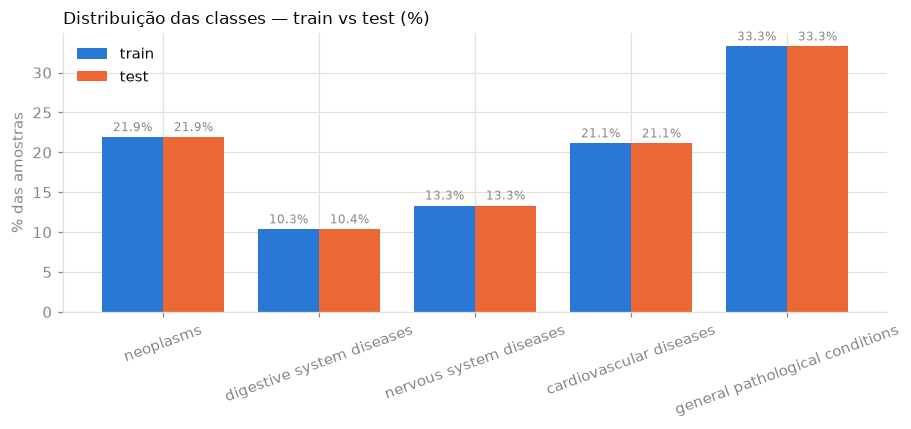

Razão de desbalanceamento (maior/menor classe no train): 3.2x


In [6]:
class_order = labels["condition_name"].tolist()

prop = pd.DataFrame({
    "train": train["condition_name"].value_counts(normalize=True),
    "test": test["condition_name"].value_counts(normalize=True),
}).loc[class_order] * 100

fig, ax = plt.subplots(figsize=(8.5, 4))
prop.plot.bar(ax=ax, color=[BLUE, ORANGE], width=0.78)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=8, color=MUTED, padding=2)
ax.set_title("Distribuição das classes — train vs test (%)", loc="left", fontsize=11)
ax.set_xlabel("")
ax.set_ylabel("% das amostras")
ax.tick_params(axis="x", rotation=20)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

ratio = train["condition_name"].value_counts().max() / train["condition_name"].value_counts().min()
print(f"Razão de desbalanceamento (maior/menor classe no train): {ratio:.1f}x")

**Achados:** desbalanceamento moderado (3,2x) e distribuições train/test alinhadas (sem shift). Decorrências para a modelagem: **F1 macro** como métrica primária, `class_weight="balanced"` nos modelos e validação cruzada **estratificada**. Técnicas de reamostragem não se justificam neste nível de desbalanceamento.

## 4. Comprimento dos textos

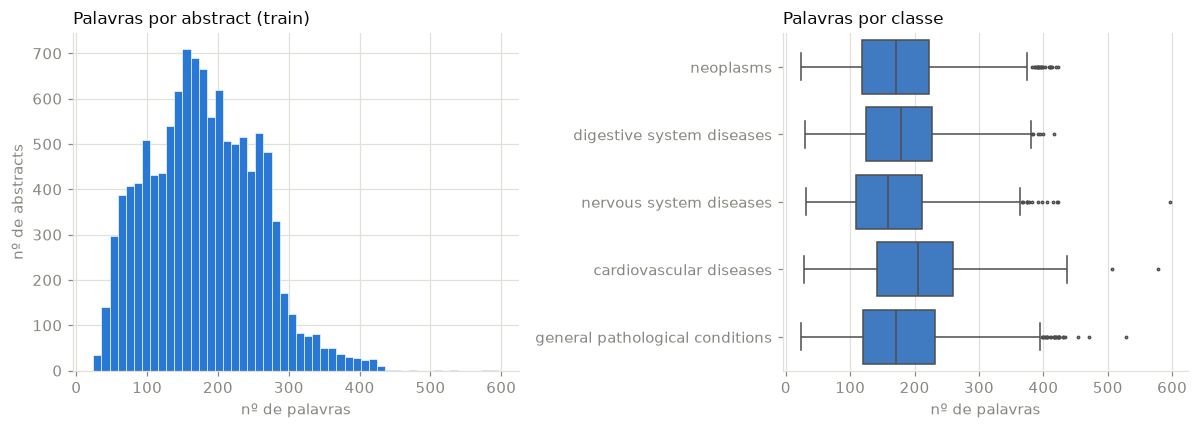

count    11550.0
mean       179.6
std         76.4
min         24.0
25%        122.0
50%        175.0
75%        234.0
max        596.0
Name: n_words, dtype: float64

In [7]:
train["n_words"] = train["medical_abstract"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1.1, 1]})

axes[0].hist(train["n_words"], bins=50, color=BLUE, edgecolor="white", linewidth=0.4)
axes[0].set_title("Palavras por abstract (train)", loc="left", fontsize=11)
axes[0].set_xlabel("nº de palavras")
axes[0].set_ylabel("nº de abstracts")

sns.boxplot(data=train, y="condition_name", x="n_words", order=class_order,
            color=BLUE, linewidth=1, fliersize=1.5, ax=axes[1])
axes[1].set_title("Palavras por classe", loc="left", fontsize=11)
axes[1].set_xlabel("nº de palavras")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

train["n_words"].describe().round(1)

**Achados:** mediana de ~180 palavras, sem extremos relevantes e sem variação sistemática de comprimento entre classes (o comprimento não é um proxy de classe). TF-IDF é adequado sem truncamento; o custo de vetorização por requisição na API será baixo.

## 5. Separabilidade lexical

Termos com maior TF-IDF médio dentro de cada classe (train vetorizado com stop-words em inglês e `min_df=5`). O objetivo é verificar, antes de qualquer modelo, se as classes possuem vocabulários distinguíveis.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vec = TfidfVectorizer(stop_words="english", min_df=5)
X = vec.fit_transform(train["medical_abstract"])
terms = np.array(vec.get_feature_names_out())
print(f"Vocabulário (stop-words + min_df=5): {len(terms):,} termos")

top_terms = {}
for lbl, name in label_map.items():
    mask = (train["condition_label"] == lbl).to_numpy()
    mean_tfidf = np.asarray(X[mask].mean(axis=0)).ravel()
    top_terms[name] = terms[mean_tfidf.argsort()[::-1][:12]]

pd.DataFrame(top_terms)

Vocabulário (stop-words + min_df=5): 12,463 termos


,neoplasms,digestive system diseases,nervous system diseases,cardiovascular diseases,general pathological conditions
0,patients,patients,patients,patients,patients
1,cancer,disease,pain,coronary,group
2,tumor,liver,brain,pressure,treatment
3,cell,gastric,cerebral,ventricular,disease
4,carcinoma,hepatitis,syndrome,artery,cases
5,cells,esophageal,disease,blood,acute
6,tumors,bowel,stroke,heart,patient
7,cases,biliary,nerve,hypertension,syndrome
8,breast,treatment,treatment,myocardial,years
9,survival,patient,patient,left,study


**Achados:** vocabulários fortemente temáticos em 4 das 5 classes (*tumor/carcinoma*, *coronary/ventricular*, *hepatic/gastric*, *cerebral/stroke*) — sinal favorável a um modelo linear sobre TF-IDF. `general pathological conditions` é a exceção: seus termos dominantes são genéricos (*patients, group, treatment*), consistente com um papel de classe residual. **Hipótese registrada:** essa classe concentrará os erros de classificação (verificação no notebook 04).

## 6. Síntese e decisões

| # | Achado | Decisão |
|---|--------|---------|
| 1 | Dataset multi-label achatado: 20,7% dos textos únicos com 2+ labels; 100% da sobreposição train/test com labels discordantes | Dedup do train + remoção da sobreposição; test intacto; teto de desempenho documentado |
| 2 | Desbalanceamento 3,2x, sem shift train/test | F1 macro como métrica primária; `class_weight="balanced"`; CV estratificada |
| 3 | Textos ~180 palavras, sem extremos | TF-IDF sem truncamento |
| 4 | Vocabulário ~12k termos (min_df=5); classes lexicalmente separáveis | Baseline linear sobre TF-IDF |
| 5 | `general pathological conditions` é classe residual | Hipótese de concentração de erros — verificar na avaliação final |

**Próximo:** `02_baseline.ipynb` — protocolo de validação, pisos de referência e baseline TF-IDF + Regressão Logística.